## Importing the data

In [38]:
import yfinance as yf
import pandas as pd
import datetime as dt
path=r"C:\Users\nisha\Desktop\2026 PS-II\Projects\VaR\pythonProject1\data"

ticker="^GSPC"
end_period = dt.date.today()
beg_period = end_period - dt.timedelta(days=30*365)
Data=pd.DataFrame
Data=yf.download(ticker,start=beg_period,end=end_period)
print(Data)

C:\Users\nisha\AppData\Local\Temp\ipykernel_14140\2643662148.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Data=yf.download(ticker,start=beg_period,end=end_period)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
1996-01-08   618.460022   618.460022   616.489990   616.710022   130360000
1996-01-09   609.450012   619.150024   608.210022   618.460022   417400000
1996-01-10   598.479980   609.450012   597.289978   609.450012   496830000
1996-01-11   602.690002   602.710022   597.539978   598.479980   408800000
1996-01-12   601.809998   604.799988   597.460022   602.690002   383400000
...                 ...          ...          ...          ...         ...
2025-12-22  6878.490234  6882.029785  6855.740234  6865.209961  4465030000
2025-12-23  6909.790039  6910.879883  6868.810059  6872.410156  3820560000
2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156  1798270000
2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020  2586550000
2025-12-29  6905.740234  

## Adding Features

### Daily Returns

In [39]:
#adding returns
import numpy as np
Data["Return"]=(np.log(Data["Close"]/Data["Close"].shift(1)))*100
Data.dropna(inplace=True)

### Rolling GARCH (1,1)

In [40]:
import numpy as np
from arch import arch_model

# Inputs
window_size = 1260  
test_start = window_size
total_days = len(Data)

# Store results
rolling_volatility = []
dates = []
current_params = {}


#The Loop
for i in range(test_start, total_days):
    #RE-FIT (Every 30 days)
    if (i - test_start) % 30 == 0:
        # Use the last 5 years of data to tune the model
        train_window = Data["Return"].iloc[i-window_size : i]
        
        model = arch_model(train_window, mean='Zero', vol='GARCH', p=1, q=1, dist='t')
        res = model.fit(disp='off')
        
        # Save new parameters
        current_params = {
            'omega': res.params['omega'],
            'alpha': res.params['alpha[1]'],
            'beta': res.params['beta[1]']
        }
        
        # Reset current variance to the model's last estimate
        current_variance = res.conditional_volatility.iloc[-1]**2

    # MANUAL RECURSION (Daily Update)
    # Get yesterday's actual return
    yesterday_return = Data["Return"].iloc[i-1]
    
    # Calculate Variance for Today using GARCH formula
    # sigma^2_t = omega + alpha * r^2_{t-1} + beta * sigma^2_{t-1}
    next_variance = (current_params['omega'] + 
                     current_params['alpha'] * (yesterday_return**2) + 
                     current_params['beta'] * current_variance)
    
    # Store Volatility (Standard Deviation)
    rolling_volatility.append(np.sqrt(next_variance))
    dates.append(Data.index[i])
    
    # Update variance for tomorrow's loop
    current_variance = next_variance

Data['Rolling_GARCH_Vol'] = np.nan

#Find the integer location of the new column
col_loc = Data.columns.get_loc('Rolling_GARCH_Vol')

# Assign by position
Data.iloc[test_start:, col_loc] = rolling_volatility


print(Data)

Price             Close         High          Low         Open      Volume  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC   
Date                                                                         
1996-01-09   609.450012   619.150024   608.210022   618.460022   417400000   
1996-01-10   598.479980   609.450012   597.289978   609.450012   496830000   
1996-01-11   602.690002   602.710022   597.539978   598.479980   408800000   
1996-01-12   601.809998   604.799988   597.460022   602.690002   383400000   
1996-01-15   599.820007   603.429993   598.469971   601.809998   306180000   
...                 ...          ...          ...          ...         ...   
2025-12-22  6878.490234  6882.029785  6855.740234  6865.209961  4465030000   
2025-12-23  6909.790039  6910.879883  6868.810059  6872.410156  3820560000   
2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156  1798270000   
2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020  

### Risk Metric Vol

In [41]:
# 1. Set the Decay Factor (Standard RiskMetrics lambda = 0.94)
lambda_param = 0.94

# 2. Convert Lambda to Pandas 'alpha' (alpha = 1 - lambda)
# Pandas formula: y_t = (1 - alpha)*y_{t-1} + alpha*x_t
# RiskMetrics:    var_t = lambda * var_{t-1} + (1-lambda) * r^2_{t-1}
# So, Pandas alpha is exactly (1 - lambda)
ewm_alpha = 1 - lambda_param

# 3. Calculate Variance (Squared Returns)
# Note: We use the percentage returns directly
squared_returns = Data["Return"]**2

# 4. Calculate EWMA Variance
# adjust=False mimics the recursive RiskMetrics definition perfectly
# shift(1) ensures we are using PAST data to predict CURRENT volatility
conditional_variance_rm = squared_returns.ewm(alpha=ewm_alpha, adjust=False).mean().shift(1)

# 5. Take Square Root to get Volatility
Data['RiskMetrics_Vol'] = np.sqrt(conditional_variance_rm)

print (Data)

Price             Close         High          Low         Open      Volume  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC   
Date                                                                         
1996-01-09   609.450012   619.150024   608.210022   618.460022   417400000   
1996-01-10   598.479980   609.450012   597.289978   609.450012   496830000   
1996-01-11   602.690002   602.710022   597.539978   598.479980   408800000   
1996-01-12   601.809998   604.799988   597.460022   602.690002   383400000   
1996-01-15   599.820007   603.429993   598.469971   601.809998   306180000   
...                 ...          ...          ...          ...         ...   
2025-12-22  6878.490234  6882.029785  6855.740234  6865.209961  4465030000   
2025-12-23  6909.790039  6910.879883  6868.810059  6872.410156  3820560000   
2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156  1798270000   
2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020  

### Adding VIX

In [42]:
import yfinance as yf
import numpy as np
import pandas as pd


# If Data has MultiIndex columns (tuples), flatten them to simple strings
if isinstance(Data.columns, pd.MultiIndex):
    Data.columns = Data.columns.get_level_values(0)
    print("Fixed: Data columns flattened to single level.")

# Now safely remove US_VIX if it exists (to start fresh)
if 'US_VIX' in Data.columns:
    Data.drop(columns=['US_VIX'], inplace=True)
if 'VIX_Daily' in Data.columns:
    Data.drop(columns=['VIX_Daily'], inplace=True)


# Download
vix_data = yf.download("^VIX", start=beg_period, end=end_period, progress=False)

# Extract 'Close'
vix_series = vix_data['Close']
if isinstance(vix_series, pd.DataFrame):
    vix_series = vix_series.iloc[:, 0]

# Rename it for the join
vix_series.name = 'US_VIX'


# Join to Data (Dates will align automatically)
Data = Data.join(vix_series, how='left')

# Drop missing VIX days (usually holidays or early data gaps)
Data.dropna(subset=['US_VIX'], inplace=True)

# Calculate the feature: Annualized VIX -> Daily % Volatility
Data['VIX_Daily'] = Data['US_VIX'] / np.sqrt(252)

# Optional: Cleanup raw column
Data.drop(columns=['US_VIX'], inplace=True)

print(Data)

Fixed: Data columns flattened to single level.
                  Close         High          Low         Open      Volume  \
Date                                                                         
1996-01-09   609.450012   619.150024   608.210022   618.460022   417400000   
1996-01-10   598.479980   609.450012   597.289978   609.450012   496830000   
1996-01-11   602.690002   602.710022   597.539978   598.479980   408800000   
1996-01-12   601.809998   604.799988   597.460022   602.690002   383400000   
1996-01-15   599.820007   603.429993   598.469971   601.809998   306180000   
...                 ...          ...          ...          ...         ...   
2025-12-22  6878.490234  6882.029785  6855.740234  6865.209961  4465030000   
2025-12-23  6909.790039  6910.879883  6868.810059  6872.410156  3820560000   
2025-12-24  6932.049805  6937.319824  6904.910156  6904.910156  1798270000   
2025-12-26  6929.939941  6945.770020  6921.600098  6936.020020  2586550000   
2025-12-29  6905.

C:\Users\nisha\AppData\Local\Temp\ipykernel_14140\4230103095.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_data = yf.download("^VIX", start=beg_period, end=end_period, progress=False)


In [43]:
Data.drop(columns=['High', 'Low', 'Open', 'Volume'], inplace=True)
print(Data)

                  Close    Return  Rolling_GARCH_Vol  RiskMetrics_Vol  \
Date                                                                    
1996-01-09   609.450012 -1.467562                NaN              NaN   
1996-01-10   598.479980 -1.816386                NaN         1.467562   
1996-01-11   602.690002  0.700990                NaN         1.490795   
1996-01-12   601.809998 -0.146120                NaN         1.455543   
1996-01-15   599.820007 -0.331215                NaN         1.411655   
...                 ...       ...                ...              ...   
2025-12-22  6878.490234  0.641587           0.812257         0.752816   
2025-12-23  6909.790039  0.454007           0.803678         0.746609   
2025-12-24  6932.049805  0.321630           0.781839         0.732357   
2025-12-26  6929.939941 -0.030441           0.754953         0.714404   
2025-12-29  6905.740234 -0.349816           0.723082         0.692681   

            VIX_Daily  
Date                   
19

### Adding RSI (Momentum Indicator)

In [44]:
delta = Data['Return']

# Separate gains (positive returns) and losses (negative returns)
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

# Calculate Relative Strength (RS)
rs = gain / loss

# Calculate RSI
Data['RSI'] = (100 - (100 / (1 + rs)))/100
Data.dropna()
Data.to_csv(path+'\\'+'Data_with_features.csv')
print(Data)

                  Close    Return  Rolling_GARCH_Vol  RiskMetrics_Vol  \
Date                                                                    
1996-01-09   609.450012 -1.467562                NaN              NaN   
1996-01-10   598.479980 -1.816386                NaN         1.467562   
1996-01-11   602.690002  0.700990                NaN         1.490795   
1996-01-12   601.809998 -0.146120                NaN         1.455543   
1996-01-15   599.820007 -0.331215                NaN         1.411655   
...                 ...       ...                ...              ...   
2025-12-22  6878.490234  0.641587           0.812257         0.752816   
2025-12-23  6909.790039  0.454007           0.803678         0.746609   
2025-12-24  6932.049805  0.321630           0.781839         0.732357   
2025-12-26  6929.939941 -0.030441           0.754953         0.714404   
2025-12-29  6905.740234 -0.349816           0.723082         0.692681   

            VIX_Daily       RSI  
Date            

## USING LSTM TO PREDICT VAR

### Setting up data and sets

In [45]:
from sklearn.preprocessing import MinMaxScaler

features = ['Return', 'Rolling_GARCH_Vol', 'RiskMetrics_Vol', 'VIX_Daily', 'RSI']
target = 'Return'

lstm_data = Data[features].copy()
lstm_data.dropna(inplace=True)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(lstm_data)

#Create Sequences
# X: (Past 60 days of features) -> Y: (Next day's Return)
X = []
y = []
window_size = 60
for i in range(window_size, len(scaled_data)):
    # Append the past 60 days of ALL features
    X.append(scaled_data[i-window_size:i, :])
    # Append the Target (Return) of the CURRENT day (i)
    y.append(scaled_data[i, 0])
    
X, y = np.array(X), np.array(y) 

split_idx = int(len(X) * 0.8) # 80% Train, 20% Test

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"X_train shape: {X_train.shape} (Samples, Timesteps, Features)")

X_train shape: (4978, 60, 5) (Samples, Timesteps, Features)


### Loss Function

In [46]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

alpha=0.015

# The Loss Function
def quantile_loss(q, y_true, y_pred):
    error = y_true - y_pred
    return tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))

# We wrap it so Keras can use it with a fixed 'q'
def quantile_loss_1pct(y_true, y_pred):
    return quantile_loss(alpha, y_true, y_pred)

### Model

In [47]:
# Initialize Model
model = Sequential()

# Layer 1: LSTM with Return Sequences=True (to stack another LSTM)
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=64, return_sequences=True, activation='tanh'))
model.add(Dropout(0.2)) # Prevent overfitting

# Layer 2: LSTM (Last hidden state only)
model.add(LSTM(units=32, activation='tanh'))
model.add(Dropout(0.2))

# Layer 3: Output (1 Neuron = The VaR Value)
model.add(Dense(units=1))

# Compile with our Custom Loss
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=quantile_loss_1pct)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [48]:
history = model.fit(
    X_train, y_train,
    epochs=20,           # Start with 20, increase if loss is still dropping
    batch_size=32,       # Standard batch size
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0035 - val_loss: 0.0025
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0028 - val_loss: 0.0022
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0026 - val_loss: 0.0021
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - loss: 0.0024 - val_loss: 0.0030
Epoch 9/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 10/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 11/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0025 - val_loss: 0.0022
Epoch 12/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 

In [49]:
# 1. Generate Scaled Predictions (Output is 0 to 1)
lstm_pred_scaled = model.predict(X, verbose=0)

#Inverse Transform 
# We need this step because the scaler expects 5 columns, but we only have 1 prediction.
dummy_matrix = np.zeros((len(lstm_pred_scaled), 5))
dummy_matrix[:, 0] = lstm_pred_scaled.flatten()

# Extract the real values 
lstm_pred_real = scaler.inverse_transform(dummy_matrix)[:, 0]

# 3. Assign to DataFrame 
Data['LSTM_VaR_99'] = np.nan 
col_loc = Data.columns.get_loc('LSTM_VaR_99')
n_preds = len(lstm_pred_real)

# Fill the last n_preds rows
Data.iloc[-n_preds:, col_loc] = lstm_pred_real

# 4. Check the Results
print(Data[['Return', 'LSTM_VaR_99']].tail())

              Return  LSTM_VaR_99
Date                             
2025-12-22  0.641587    -2.404484
2025-12-23  0.454007    -2.309919
2025-12-24  0.321630    -2.211874
2025-12-26 -0.030441    -2.121398
2025-12-29 -0.349816    -2.068143


## BACKTEST

In [50]:
# 1. Clean Data for Backtest 
backtest_data = Data.dropna(subset=['LSTM_VaR_99', 'Return']).copy()

# 2. Identify "Hits" 
backtest_data['Breach'] = backtest_data['Return'] < backtest_data['LSTM_VaR_99']

# 3. Calculate Statistics
total_days = len(backtest_data)
expected_breaches = total_days * 0.01  
actual_breaches = backtest_data['Breach'].sum()
failure_rate = actual_breaches / total_days

print("--- Backtest Results (99% VaR) ---")
print(f"Total Days Evaluated:  {total_days}")
print(f"Expected Breaches:     {int(expected_breaches)}")
print(f"Actual Breaches:       {actual_breaches}")
print(f"Failure Rate:          {failure_rate:.2%}")

--- Backtest Results (99% VaR) ---
Total Days Evaluated:  6223
Expected Breaches:     62
Actual Breaches:       57
Failure Rate:          0.92%


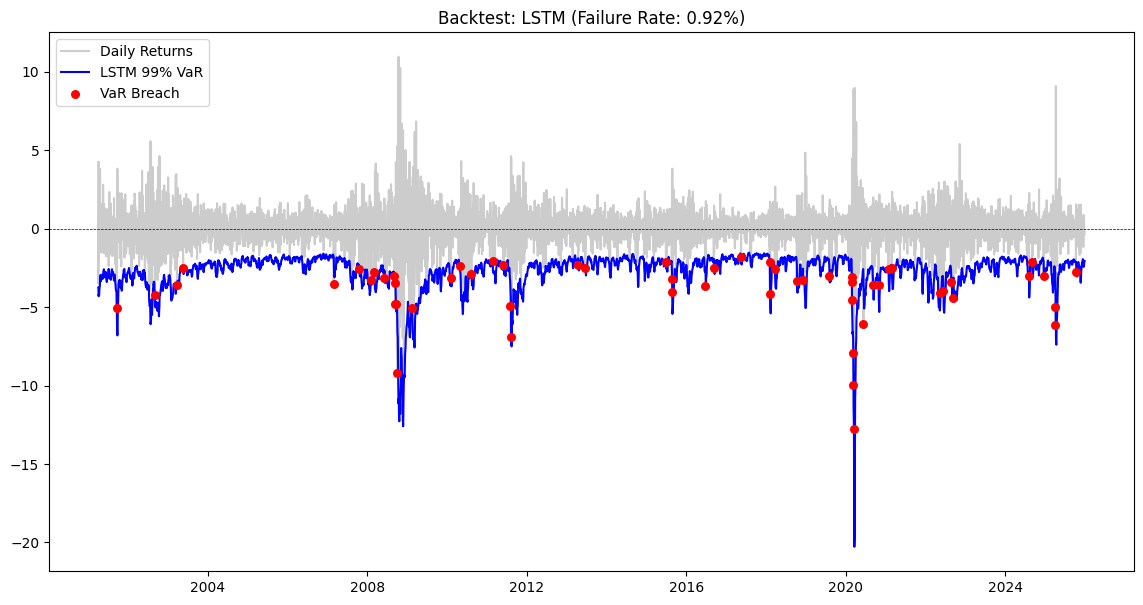

In [52]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 7))
plt.plot(backtest_data.index, backtest_data['Return'], color='gray', alpha=0.4, label='Daily Returns')
plt.plot(backtest_data.index, backtest_data['LSTM_VaR_99'], color='blue', linewidth=1.5, label='LSTM 99% VaR')

# Highlight Breaches
breach_data = backtest_data[backtest_data['Breach'] == 1]
plt.scatter(breach_data.index, breach_data['Return'], color='red', s=30, label='VaR Breach', zorder=5)

plt.title(f'Backtest: LSTM (Failure Rate: {failure_rate:.2%})')
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.show()